In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
"""
Semi-Supervised Clustering using PCA + Label Spreading
=======================================================

WHAT'S NEW IN THIS VERSION:
- After scaling the 20 sensors, we use PCA to reduce them to fewer "super-features"
- This removes noise and helps Label Spreading find better patterns
- We also try different numbers of PCA components to find the best one

SIMPLE ANALOGY:
Imagine you're trying to recognize someone's face from 20 different camera angles.
Some angles are useless (back of head), some are great (front face).
PCA is like picking the best 8 camera angles that together give you the clearest picture.
"""

# --------------------------------------------------
# IMPORTS: Loading the tools we need
# --------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.semi_supervised import LabelSpreading
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
# --------------------------------------------------
# STEP 1: LOAD THE DATA
# --------------------------------------------------
print("=" * 60)
print("SEMI-SUPERVISED CLUSTERING: PCA + LABEL SPREADING")
print("=" * 60)

df = pd.read_csv('/content/drive/MyDrive/Take-Home-Assignment/ML6/Customer-A/data_sensors.csv')

sensor_cols = [f'Sensor {i}' for i in range(20)]
X = df[sensor_cols].values
y_original = df['Label'].values

print(f"\nDataset loaded successfully!")
print(f"  Total breakdowns: {len(X)}")
print(f"  Number of sensors: {X.shape[1]}")
print(f"  Labeled breakdowns: {np.sum(~np.isnan(y_original))}")
print(f"  Unlabeled breakdowns: {np.sum(np.isnan(y_original))}")

SEMI-SUPERVISED CLUSTERING: PCA + LABEL SPREADING

Dataset loaded successfully!
  Total breakdowns: 1600
  Number of sensors: 20
  Labeled breakdowns: 40
  Unlabeled breakdowns: 1560


In [ ]:
# --------------------------------------------------
# STEP 2: PREPARE THE LABELS
# --------------------------------------------------
y_for_model = np.copy(y_original)
y_for_model[np.isnan(y_for_model)] = -1
y_for_model = y_for_model.astype(int)

print(f"\nLabel preparation:")
print(f"  Points marked as 'known' (labeled): {np.sum(y_for_model != -1)}")
print(f"  Points marked as 'unknown' (-1): {np.sum(y_for_model == -1)}")


Label preparation:
  Points marked as 'known' (labeled): 40
  Points marked as 'unknown' (-1): 1560


In [ ]:
# --------------------------------------------------
# STEP 3: SCALE THE DATA
# --------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nData scaled: all sensors now have mean≈0 and std≈1")


Data scaled: all sensors now have mean≈0 and std≈1



STEP 4: PCA — REDUCING 20 SENSORS TO FEWER SUPER-FEATURES

Information captured by each PCA component:
--------------------------------------------------
  Component  1:  6.11% (Cumulative:  6.11%)
  Component  2:  5.89% (Cumulative: 12.00%)
  Component  3:  5.74% (Cumulative: 17.74%)
  Component  4:  5.56% (Cumulative: 23.30%)
  Component  5:  5.47% (Cumulative: 28.77%)
  Component  6:  5.36% (Cumulative: 34.13%)
  Component  7:  5.28% (Cumulative: 39.42%)
  Component  8:  5.18% (Cumulative: 44.60%)
  Component  9:  5.16% (Cumulative: 49.76%)
  Component 10:  5.09% (Cumulative: 54.85%)
  Component 11:  4.92% (Cumulative: 59.77%)
  Component 12:  4.81% (Cumulative: 64.57%)
  Component 13:  4.76% (Cumulative: 69.34%)
  Component 14:  4.57% (Cumulative: 73.91%)
  Component 15:  4.56% (Cumulative: 78.47%)
  Component 16:  4.48% (Cumulative: 82.95%)
  Component 17:  4.44% (Cumulative: 87.39%)
  Component 18:  4.31% (Cumulative: 91.70%)
  Component 19:  4.22% (Cumulative: 95.92%)
  Compone

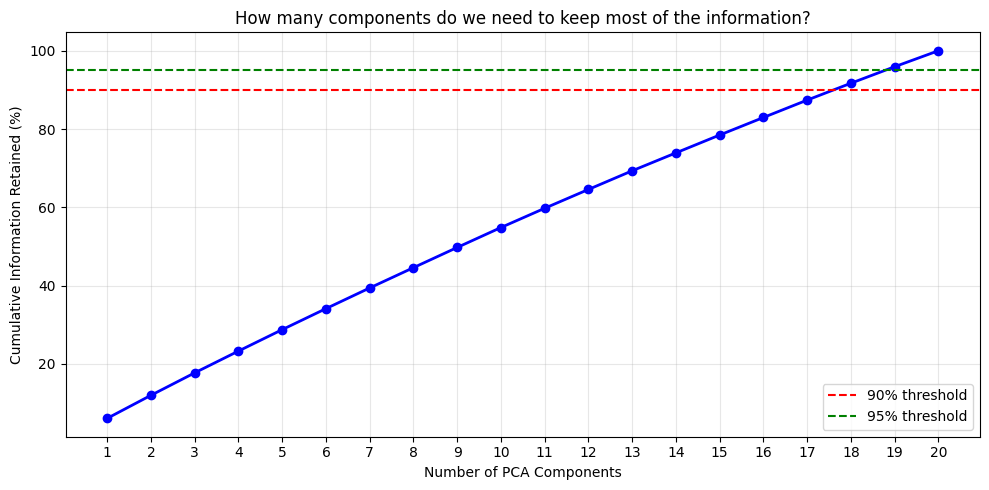

In [ ]:
# --------------------------------------------------
# STEP 4: APPLY PCA (NEW STEP!)
# --------------------------------------------------
# This is where we reduce 20 sensors into fewer "super-features".
#
# HOW PCA WORKS:
# 1. It looks at all 20 sensors and finds which combinations carry the most info
# 2. It creates new features (components) ranked by importance
# 3. Component 1 = the single most informative mix of all 20 sensors
# 4. Component 2 = the second most informative mix (different from #1)
# 5. And so on...
# 6. We keep only the top N components and throw away the rest (noise)
#
# FIRST: Let's see how much information each component carries
# so we can decide how many to keep.

print(f"\n{'=' * 60}")
print("STEP 4: PCA — REDUCING 20 SENSORS TO FEWER SUPER-FEATURES")
print("=" * 60)

# Run PCA with all 20 components first, just to see how much info each carries
pca_full = PCA(n_components=20)
pca_full.fit(X_scaled)

# This shows what % of total information each component captures
print(f"\nInformation captured by each PCA component:")
print("-" * 50)
cumulative = 0
for i, var in enumerate(pca_full.explained_variance_ratio_):
    cumulative += var
    print(f"  Component {i+1:2d}: {var*100:5.2f}% (Cumulative: {cumulative*100:5.2f}%)")

# Plot the cumulative variance to visualize the "elbow"
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), np.cumsum(pca_full.explained_variance_ratio_) * 100, 'bo-', linewidth=2)
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Information Retained (%)')
plt.title('How many components do we need to keep most of the information?')
plt.axhline(y=90, color='r', linestyle='--', label='90% threshold')
plt.axhline(y=95, color='g', linestyle='--', label='95% threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 21))
plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------
# STEP 5: FIND THE BEST NUMBER OF PCA COMPONENTS
#          BY TESTING ACCURACY FOR EACH
# --------------------------------------------------
# We try different numbers of components (2 to 15) and for each one,
# we run Label Spreading with Leave-One-Out to see which gives best accuracy.
#
# Think of it like trying different zoom levels on a camera —
# too zoomed in (few components) = you miss details
# too zoomed out (many components) = you see noise
# We want the sweet spot.

print(f"\n{'=' * 60}")
print("STEP 5: FINDING BEST NUMBER OF PCA COMPONENTS")
print("=" * 60)
print("For each number of components, we test Label Spreading accuracy...\n")

# Get labeled indices
labeled_indices = np.where(y_for_model != -1)[0]
y_labeled = y_for_model[labeled_indices]

# We'll use the best hyperparameters you already found
# (Update these to your best values from the previous tuning)
best_kernel = 'knn'
best_gamma = 100
best_alpha = 0.7

print(f"Using hyperparameters: kernel={best_kernel}, gamma={best_gamma}, alpha={best_alpha}")
print("-" * 60)

component_results = []

for n_components in range(2, 16):
    # Apply PCA to reduce dimensions
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    info_retained = sum(pca.explained_variance_ratio_) * 100

    # Run Leave-One-Out with Label Spreading on the PCA-reduced data
    correct = 0
    for i in range(len(labeled_indices)):
        y_test = np.copy(y_for_model)
        y_test[labeled_indices[i]] = -1

        model_test = LabelSpreading(kernel=best_kernel, gamma=best_gamma,
                                    alpha=best_alpha, max_iter=1000)
        model_test.fit(X_pca, y_test)

        predicted = model_test.transduction_[labeled_indices[i]]
        if predicted == y_labeled[i]:
            correct += 1

    accuracy = correct / len(labeled_indices) * 100
    component_results.append((n_components, accuracy, info_retained))

    print(f"  Components: {n_components:2d} | Info retained: {info_retained:5.1f}% | "
          f"Accuracy: {accuracy:.1f}% (Results: {correct}/{len(labeled_indices)} correct)")

# Find the best number of components
best_n = max(component_results, key=lambda x: x[1])
best_n_components = best_n[0]
best_pca_accuracy = best_n[1]

print(f"\n{'=' * 60}")
print(f"BEST: {best_n_components} components → Accuracy: {best_pca_accuracy:.1f}%")
print(f"(Information retained: {best_n[2]:.1f}%)")
print("=" * 60)


STEP 5: FINDING BEST NUMBER OF PCA COMPONENTS
For each number of components, we test Label Spreading accuracy...

Using hyperparameters: kernel=knn, gamma=100, alpha=0.7
------------------------------------------------------------
  Components:  2 | Info retained:  12.0% | Accuracy: 35.0% (Results: 14/40 correct)
  Components:  3 | Info retained:  17.7% | Accuracy: 35.0% (Results: 14/40 correct)
  Components:  4 | Info retained:  23.3% | Accuracy: 25.0% (Results: 10/40 correct)
  Components:  5 | Info retained:  28.8% | Accuracy: 35.0% (Results: 14/40 correct)
  Components:  6 | Info retained:  34.1% | Accuracy: 37.5% (Results: 15/40 correct)
  Components:  7 | Info retained:  39.4% | Accuracy: 35.0% (Results: 14/40 correct)
  Components:  8 | Info retained:  44.6% | Accuracy: 40.0% (Results: 16/40 correct)
  Components:  9 | Info retained:  49.8% | Accuracy: 42.5% (Results: 17/40 correct)
  Components: 10 | Info retained:  54.8% | Accuracy: 35.0% (Results: 14/40 correct)
  Components

## Considering the Accuracy is better without PCA, hence there is no need to do PCA

# The End